# Задание 2

## Параметры модели HMM

In [2]:
import numpy as np
import matplotlib.pyplot as plt

states   = ['E', '5', 'I']
alphabet = ['A', 'C', 'G', 'T']

pi = np.array([1.0, 0.0, 0.0])

A = np.array([
    [0.9, 0.1, 0.0],  
    [0.0, 0.0, 1.0],   
    [0.0, 0.0, 0.9]])

B = np.array([
    [0.25,  0.25,  0.25,  0.25],   
    [0.05,  0.00,  0.95,  0.00],   
    [0.40,  0.10,  0.10,  0.40]])

end_prob = np.array([0.0, 0.0, 0.1])

log_pi  = np.log(pi + 1e-300)
log_A   = np.log(A + 1e-300)
log_B   = np.log(B + 1e-300)
log_end = np.log(end_prob + 1e-300)

sequence = 'CTTCATGTGAAAGCAGACGTAAGTCA'
obs_idx  = {c: i for i, c in enumerate(alphabet)}
obs      = np.array([obs_idx[c] for c in sequence])
T, N     = len(obs), len(states)

 Вспомогательная функция: log-sum-exp - вычисляет $\log\sum_i e^{a_i}$ численно устойчивым способом.

In [6]:
def log_sum_exp(log_probs):
    m = np.max(log_probs)
    if np.isneginf(m):
        return -np.inf
    return m + np.log(np.sum(np.exp(log_probs - m)))

## 2.1 Алгоритм Витерби

Находим наиболее вероятный путь скрытых состояний.

$$\delta_t(i) = \max_{s_1,\ldots,s_{t-1}} P(s_1,\ldots,s_{t-1},\,s_t=i,\,o_1,\ldots,o_t\mid\lambda)$$

Рекуррентно: $\delta_t(j) = \bigl[\max_i\,\delta_{t-1}(i)\cdot a_{ij}\bigr]\cdot b_j(o_t)$  
В конце умножаем на вероятность завершения и делаем backtracking.

In [8]:
def viterbi(obs, log_pi, log_A, log_B, log_end):
    T, N  = len(obs), log_A.shape[0]
    delta = np.full((T, N), -np.inf)  
    psi   = np.zeros((T, N), dtype=int) 

    delta[0] = log_pi + log_B[:, obs[0]]

    for t in range(1, T):
        for j in range(N):
            candidates  = delta[t-1] + log_A[:, j]
            best_prev   = np.argmax(candidates)
            psi[t, j]   = best_prev
            delta[t, j] = candidates[best_prev] + log_B[j, obs[t]]

    final_scores = delta[-1] + log_end
    log_prob     = np.max(final_scores)

    path = np.zeros(T, dtype=int)
    path[-1] = np.argmax(final_scores)
    for t in range(T - 2, -1, -1):
        path[t] = psi[t + 1, path[t + 1]]

    return path, log_prob

path, log_prob_viterbi = viterbi(obs, log_pi, log_A, log_B, log_end)
decoded = ''.join(states[i] for i in path)

In [13]:
print(f'последовательность: {sequence}')
print(f'путь витерби:       {decoded}')
print(f'log P(путь):        {log_prob_viterbi:.2f}')

splice_pos = decoded.index('5') + 1
print(f'сайт 5 на позиции {splice_pos} (нуклеотид: {sequence[splice_pos-1]})')

print('Путь из статьи Eddy 2004: EEEEEEEEEEEEEEEEEE55IIIIII')

последовательность: CTTCATGTGAAAGCAGACGTAAGTCA
путь витерби:       EEEEEEEEEEEEEEEEEE5IIIIIII
log P(путь):        -41.22
сайт 5 на позиции 19 (нуклеотид: G)
Путь из статьи Eddy 2004: EEEEEEEEEEEEEEEEEE55IIIIII


Алгоритм правильно определяет границу экзон→5'-сайт→интрон на позиции 19 (нуклеотид G), что совпадает с результатом статьи.

## 2.2 Алгоритм Forward

Вычисляем полную вероятность наблюдаемой последовательности, суммируя по всем путям.

$$\alpha_t(i) = P(o_1,\ldots,o_t,\,s_t=i\mid\lambda)$$

$$\alpha_t(j) = \Bigl[\sum_i \alpha_{t-1}(i)\cdot a_{ij}\Bigr]\cdot b_j(o_t)$$

In [15]:
def forward(obs, log_pi, log_A, log_B, log_end):
    T, N      = len(obs), log_A.shape[0]
    log_alpha = np.full((T, N), -np.inf)

    log_alpha[0] = log_pi + log_B[:, obs[0]]

    for t in range(1, T):
        for j in range(N):
            log_alpha[t, j] = (log_sum_exp(log_alpha[t-1] + log_A[:, j])
                               + log_B[j, obs[t]])

    log_prob = log_sum_exp(log_alpha[-1] + log_end)
    return log_alpha, log_prob


log_alpha, log_prob_forward = forward(obs, log_pi, log_A, log_B, log_end)

In [17]:
print(f'log P(O|λ) = {log_prob_forward:.4f}')
print(f'P(O|λ) = {np.exp(log_prob_forward):.4e}')

log P(O|λ) = -40.4474
P(O|λ) = 2.7159e-18


## 2.3 Алгоритм Backward и апостериорное декодирование

Backward идёт справа налево:

$$\beta_t(i) = P(o_{t+1},\ldots,o_T\mid s_t=i,\lambda)$$

Инициализация: $\beta_T(i)$ = вероятность завершения из состояния $i$  
(только из $I$ можно закончить: $\beta_T(I)=0.1$, остальные $= 0$).

Апостериорная вероятность:
$$\gamma_t(i) = \frac{\alpha_t(i)\cdot\beta_t(i)}{P(O\mid\lambda)}$$

In [33]:
def backward(obs, log_A, log_B, log_end):
    T, N     = len(obs), log_A.shape[0]
    log_beta = np.full((T, N), -np.inf)

    log_beta[-1] = log_end

    for t in range(T - 2, -1, -1):
        for i in range(N):
            log_beta[t, i] = log_sum_exp(
                log_A[i, :] + log_B[:, obs[t + 1]] + log_beta[t + 1]
            )

    return log_beta


log_beta  = backward(obs, log_A, log_B, log_end)

log_gamma = log_alpha + log_beta - log_prob_forward
gamma     = np.exp(log_gamma)

## Графики $\gamma_t(i)$

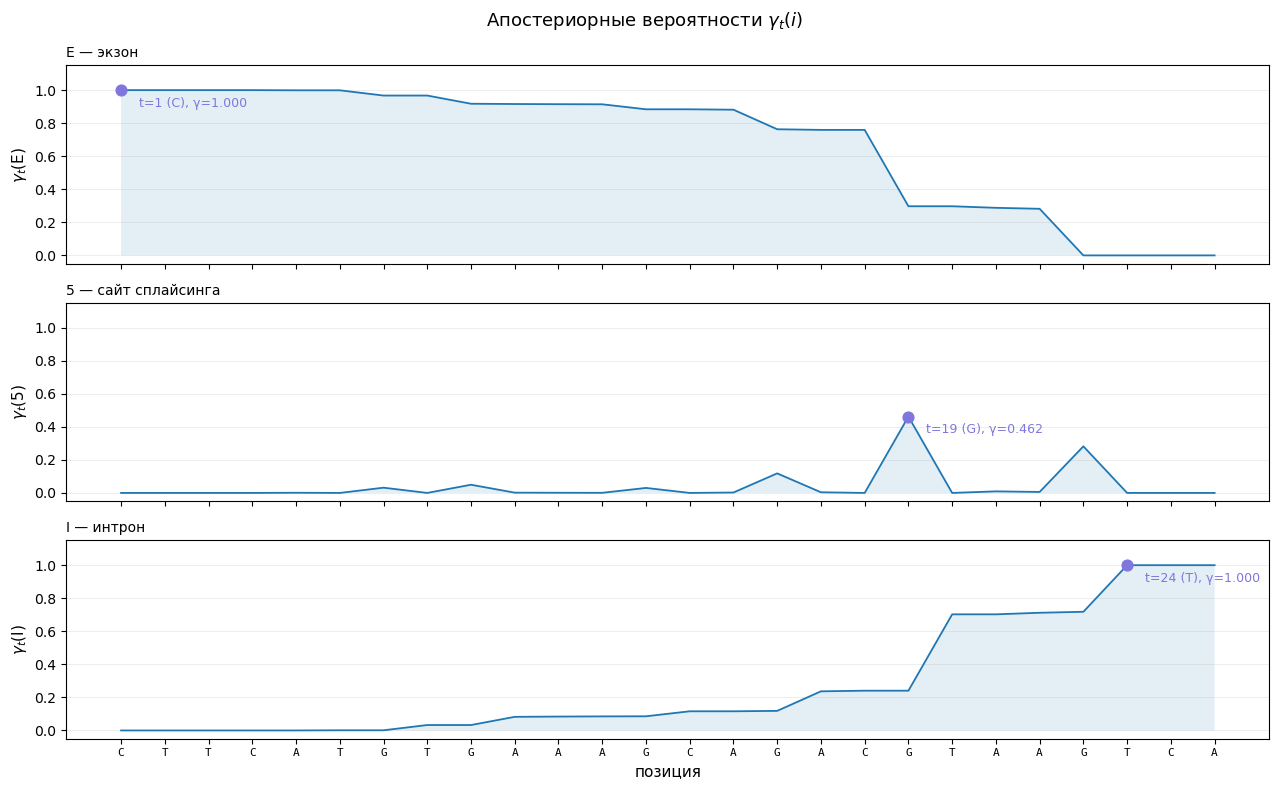

In [31]:
labels = {'E': 'E — экзон', '5': '5 — сайт сплайсинга', 'I': 'I — интрон'}
t_axis = np.arange(1, T + 1)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
fig.suptitle('Апостериорные вероятности $\gamma_t(i)$', fontsize=13)

for ax, (si, state) in zip(axes, enumerate(states)):
    probs = gamma[:, si]

    ax.plot(t_axis, probs, linewidth=1.3)
    ax.fill_between(t_axis, probs, alpha=0.12)

    t_max = int(np.argmax(probs))
    ax.scatter(t_axis[t_max], probs[t_max], color=c, zorder=5, s=60)
    ax.annotate(
        f't={t_axis[t_max]} ({sequence[t_max]}), γ={probs[t_max]:.3f}',
        xy=(t_axis[t_max], probs[t_max]),
        xytext=(t_axis[t_max] + 0.4, probs[t_max] - 0.10),
        fontsize=9, color=c)

    ax.set_ylabel(f'$\gamma_t$({state})', fontsize=11)
    ax.set_ylim(-0.05, 1.15)
    ax.set_title(labels[state], fontsize=10, loc='left')
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    ax.set_xticks(t_axis)
    ax.set_xticklabels(list(sequence), fontsize=8, fontfamily='monospace')

axes[-1].set_xlabel('позиция', fontsize=11)
plt.tight_layout()

In [35]:
print('Максимумы γ:')
for si, state in enumerate(states):
    t_max = int(np.argmax(gamma[:, si]))
    print(f'  {labels[state]:26s}  t={t_axis[t_max]:<3} ({sequence[t_max]}), γ={gamma[t_max, si]:.4f}')

Максимумы γ:
  E — экзон                   t=1   (C), γ=1.0000
  5 — сайт сплайсинга         t=19  (G), γ=0.4620
  I — интрон                  t=24  (T), γ=1.0000
